# Classification de SMS : Détection de Spams

## Sommaire
1. Introduction et Contexte
2. Imports et Configuration
3. Chargement et Prétraitement des Données
4. Analyse Exploratoire des Données (EDA)
5. Modèle Baseline : Modèle de Regression Logistique avec une vectorisation par la méthode TF-IDF
6. Modèle Deep Learning (Transformers)
7. Évaluation et Comparaison
8. Conclusion et Recommandations

## 1. Introduction et Contexte

### L'objectif de ce projet est de construire un classifieur capable de filtrer efficacement les SMS indésirables (spams). Nous analyserons d'abord les caractéristiques des messages, établirons un modèle de référence simple, puis implémenterons une solution basée sur le Deep Learning afin d'optimiser les performances.

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
import datasets

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments , EarlyStoppingCallback
from wordcloud import WordCloud



import logging
from transformers import logging as hf_logging

# Désactive les warnings de Hugging Face
hf_logging.set_verbosity_error()

## 3. Chargement et Prétraitement des Données
### 3.1. Importation du fichier source

In [2]:
# Chargement des données
df = pd.read_csv("src/spam.csv", encoding="latin-1")

# On renomme les colonnes pour plus de clarté
df = df.rename(columns={'v1': 'cible', 'v2': 'message'})

# On ne garde que les deux premières colonnes
df = df[['cible', 'message']]

print(df.head())



  cible                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


### 3.2. Vérification de la structure et nettoyage

In [3]:
#valeurs manquantes ?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   cible    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [4]:
# Conversion de la colonne  'cible' en valeurs numériques (ham=0, spam=1)
df['cible'] = df['cible'].map({'ham': 0, 'spam': 1})

# Suppression des doublons
df = df.drop_duplicates(subset=['message']).reset_index(drop=True)

# Vérification de la balance des classes
print("Distribution des classes :")
print(df['cible'].value_counts(normalize=True))



Distribution des classes :
cible
0    0.87367
1    0.12633
Name: proportion, dtype: float64


### Note sur le déséquilibre des classes :
### La cible présente un déséquilibre marqué entre les spams et les messages sains, sans toutefois atteindre un ratio extrême de 90/10.
### Pour préserver cette distribution dans nos échantillons, nous appliquerons le paramètre stratify=y lors du découpage en ensembles d'entraînement et de test.

## 4. Analyse Exploratoire des Données (EDA)
### 4.1. Analyse de la longueur des messages

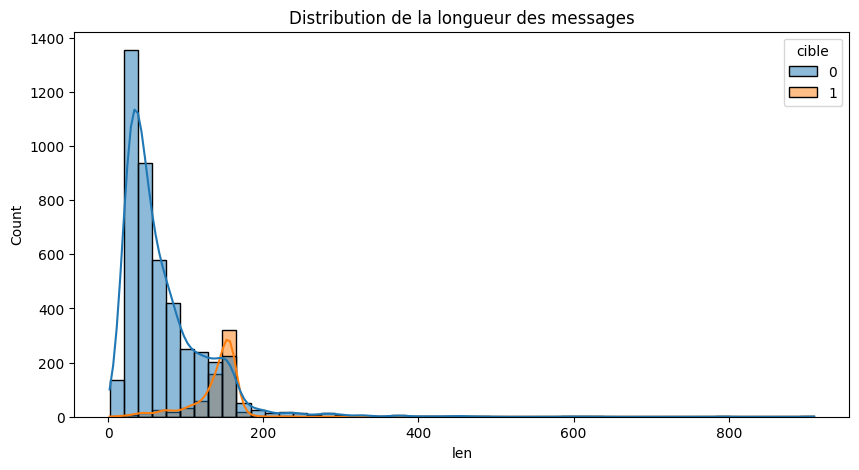

In [5]:
# Distribution de la longueur des SMS
df['len'] = df['message'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='len', hue='cible', bins=50, kde=True)
plt.title("Distribution de la longueur des messages")
plt.show()

### Ce graphique de distribution montre des écarts significatifs entre les hams et les spams.
### On voit que les hams sont plutôt centrés autour d'une taille de 40 à 60 caractères alors que les spams sont condensés sur du 140 - 160 caractères.
### Le choix de fixer un maximum de 128 tokens permet une excellente marge de sécurité pour lire la totalité des messages sans aucune perte d'information.


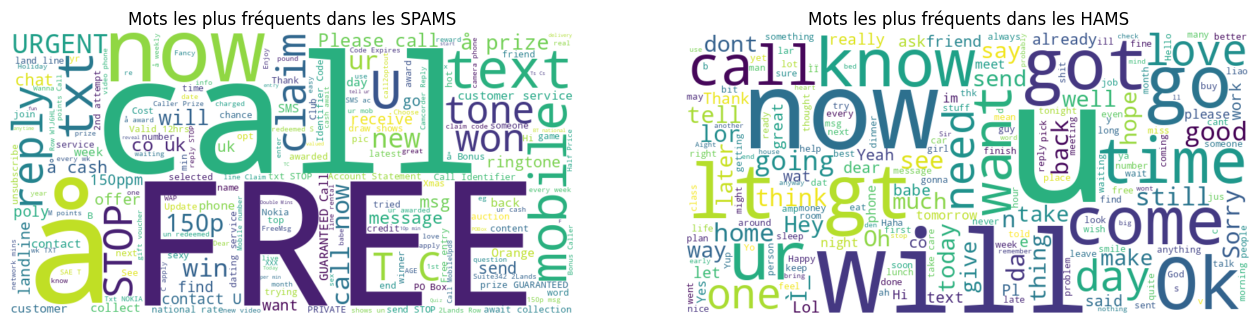

In [6]:
# Visualisation des mots fréquents
mots_spam = ' '.join(list(df[df['cible'] == 1]['message']))
mots_ham = ' '.join(list(df[df['cible'] == 0]['message']))

plt.figure(figsize=(16, 8))

# Utilisation de WorldCloud pour représenter les mots les plus fréquents dans les 'Spam'
plt.subplot(1, 2, 1)
wc_spam = WordCloud(width=800, height=400, background_color='white').generate(mots_spam)
plt.imshow(wc_spam, interpolation='bilinear')
plt.title('Mots les plus fréquents dans les SPAMS')
plt.axis('off')

# Utilisation de WorldCloud pour représenter les mots les plus fréquents dans les 'Ham'
plt.subplot(1, 2, 2)
wc_ham = WordCloud(width=800, height=400, background_color='white').generate(mots_ham)
plt.imshow(wc_ham, interpolation='bilinear')
plt.title('Mots les plus fréquents dans les HAMS')
plt.axis('off')

plt.show()

### Ce WordCloud des spams et ham met en évidence que le lexique ne suffira pas à fixer la frontière entre Spam et Ham
### Le mot 'call' très représenté et faisant parti des deux classes risque de mettre en échec le modèle de regression logistique (TF-IDF).
### Il manque le contexte, c'est la que les couches d'attention améliorent la représentation vectorielle de chaque token grâce aux mots qui l'entourent, le modèle DistriBERT doit faire la différence sur ce point.

## 5. Modèle Baseline : Modèle de Regression Logistique avec une vectorisation par la méthode TF-IDF

Proportion de spams dans le train : 0.12623941958887544
Proportion de spams dans le test : 0.12669245647969052
--- RAPPORT DE CLASSIFICATION (BASELINE) ---

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.71      0.83       131

    accuracy                           0.96      1034
   macro avg       0.97      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



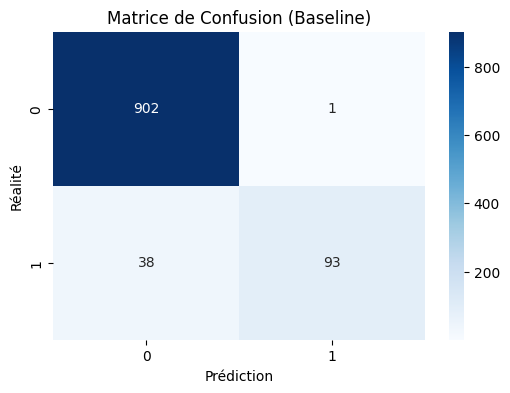

In [7]:
#séparation des variables explicatives (caractéristiques) et de la variable cible (à prédire) :
X = df['message']
y = df['cible']

# séparation des données d'entrainement et de test (tout en gardant la proportion des classes de la target 'Cible')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print("Proportion de spams dans le train :", y_train.mean())
print("Proportion de spams dans le test :", y_test.mean())

# Création de la pipeline pour préprocesser et choisir le modèle
# Le pipeline enchaîne la vectorisation et le modèle
baseline_pipeline = Pipeline([
    (
        'tfidf',# Vectorisation TF-IDF avec comme hyperparamètre : 
        TfidfVectorizer(
            stop_words='english',  #suppression des mots anglais qui ont un sens limité
            max_features=5000 #limitation à 5000 mots
            )
    ), 
    ('clf', LogisticRegression())
])

# Entraînement
baseline_pipeline.fit(X_train, y_train)

# Prédiction
y_pred = baseline_pipeline.predict(X_test)

# ÉVALUATION (Matrice de confusion & Rapport) ---
print("--- RAPPORT DE CLASSIFICATION (BASELINE) ---\n")
print(classification_report(y_test, y_pred))

# Visualisation de la matrice de confusion
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion (Baseline)')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()

### Matrice de confusion 
Si on part de la règle métier qui est d'avoir le moins de Faux Positifs (des Hams traités comme des spams), ce modèle se comporte bien avec 99% de précision sur les spams avec un seul message Ham bloqué à tort.

Mais il est malgré tout pas assez sévère en laissant passer 29% des spams.

Le modèle DistilBERT devrait avoir une meilleure compréhension du contexte avec son embedding amélioré par l'attention (exemple : faire la différence entre le mot "Call" dans un contexte commercial agressif et un contexte normal)

## 6. Modèle Deep Learning (modèle DistriBERT)

In [8]:


#Préparation des données au format Hugging Face
# les keys doivent être 'text' et 'label'
train_ds = datasets.Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train}))
test_ds = datasets.Dataset.from_pandas(pd.DataFrame({'text': X_test, 'label': y_test}))

# Choix du modèle
model_name = "distilbert-base-uncased"

#Tokenisation
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length", #le tokenizer va combler(padding) avec du vide pour atteindre 128 tokens
        truncation=True, # coupe si plus de 128 tokens
        max_length=128
        ) 

# Transformation des mots en token par lots parallélisés de 1000 sms
train_ds = train_ds.map(tokenize_function, batched=True) 
test_ds = test_ds.map(tokenize_function, batched=True)

# Configuration et entraînement
training_args = TrainingArguments(
    output_dir="./results", #dossier local pour les logs 
    eval_strategy="epoch", #fréquence d'évaluation -> à chaque epoque
    save_strategy="epoch", #fréquence de sauvegarde des poids -> à chaque époque
    learning_rate=2e-5, #le pas d'apprentissage est ici minime pour éviter de détruire l'embedding initial du modèle 
    per_device_train_batch_size=16, # 16 sms avant de faire la boucke de backward de la descente de gradient
    num_train_epochs=3, # Nombre total d'époques
    weight_decay=0.01, # coefficient lambda pour la régularisation
    load_best_model_at_end=True, # équivalent du load best estimator de la gridsearch-CV
)

# C'est ici que s'opère le transfert learning
# On force la sortie du modèle sur deux classes (ici HAM / SPAM) 
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

#Initialisation du Trainer / Pipeline
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)], # Sécurité : arrête l'entraînement si l'erreur sur le jeu de test ne diminue plus (évite l'overfitting)
)

# Lancer l'entraînement
trainer.train()

Map:   0%|          | 0/4135 [00:00<?, ? examples/s]

Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'eval_loss': '0.0345', 'eval_runtime': '0.7998', 'eval_samples_per_second': '1293', 'eval_steps_per_second': '162.5', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.0273', 'eval_runtime': '0.765', 'eval_samples_per_second': '1352', 'eval_steps_per_second': '169.9', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '36.87', 'train_samples_per_second': '336.4', 'train_steps_per_second': '21.07', 'train_loss': '0.047', 'epoch': '3'}


TrainOutput(global_step=777, training_loss=0.04700348582813945, metrics={'train_runtime': 36.8735, 'train_samples_per_second': 336.42, 'train_steps_per_second': 21.072, 'train_loss': 0.04700348582813945, 'epoch': 3.0})

## 7. Évaluation et Analyse des performances

--- RAPPORT DE CLASSIFICATION (DISTILBERT) ---

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       903
           1       0.97      0.96      0.97       131

    accuracy                           0.99      1034
   macro avg       0.98      0.98      0.98      1034
weighted avg       0.99      0.99      0.99      1034



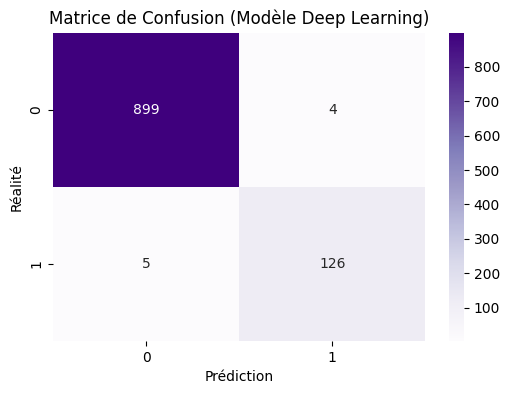

In [9]:
# On se lance dans une prédiction, ici pour obtenir des métriques, mais en production ce serait pour afficher le résultat au métier
preds_output = trainer.predict(test_ds)

# Selon la fonction argmax, on passe d'une valeur numérique (score brut) à son équivalent catégoriel (0 ou 1)
y_pred_dl = np.argmax(preds_output.predictions, axis=1)

# Extraction des vraies étiquettes
y_true = test_ds['label']

# Affichage du rapport de classification comme pour le modèle de régression logistique
print("--- RAPPORT DE CLASSIFICATION (DISTILBERT) ---\n")
print(classification_report(y_true, y_pred_dl))

# Calcul et affichage de la matrice de confusion
cm_dl = confusion_matrix(y_true, y_pred_dl)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Purples') 
plt.title('Matrice de Confusion (Modèle Deep Learning)')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()

### La matrice de confusion est globalement bien meilleur surtout au niveau de la détection des sms


Matrice Comparative entre la baseline et distriBERT

               0      1
precision  0.035 -0.020
recall    -0.003  0.252
f1-score   0.016  0.139




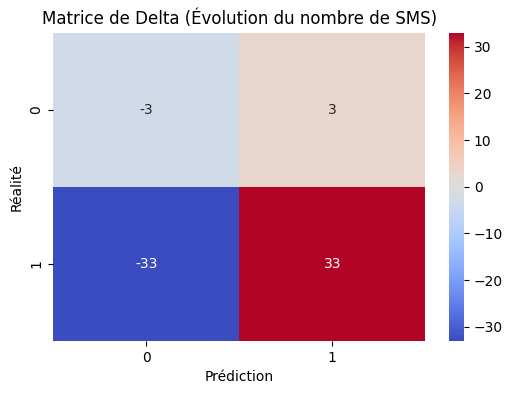

In [10]:
# Matrice Comparative entre la baseline et distriBERT

#Extraction des rapports sous forme de dictionnaires
report_bs = classification_report(y_test, y_pred, output_dict=True)
report_dl = classification_report(y_true, y_pred_dl, output_dict=True)

#Conversion en DataFrames en gardant les métriques précision/recall et F1 score
df_bs = pd.DataFrame(report_bs).iloc[:-1, :2] 
df_dl = pd.DataFrame(report_dl).iloc[:-1, :2]

#Classification_report ->  Calcul du Delta (DistriBert - Baseline)
df_delta_metrics = df_dl - df_bs

print("\nMatrice Comparative entre la baseline et distriBERT\n")
print(df_delta_metrics.round(3))
print('\n')


#Matrice de  confusion -> Calcul du Delta (DistriBert - Baseline)
cm_baseline = confusion_matrix(y_test, y_pred)
cm_dl = confusion_matrix(y_true, y_pred_dl)
cm_delta = cm_dl - cm_baseline

#Affichage de la matrice des Deltas
plt.figure(figsize=(6, 4))

sns.heatmap(cm_delta, annot=True, fmt='d', cmap='coolwarm', center=0) # Bleu = baisse, Rouge = hausse
plt.title('Matrice de Delta (Évolution du nombre de SMS)')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()




### Synthèse métier : Analyse du delta de performance

Avec 32 spams détectés de plus pour 2 hams mal classé, le modèle distribert améliore clairement le rôle de anti-spam.

Sur le plan opérationnel, nous atteignons des ratios de risque très faibles :


-> 0.4% de FauxPositifs (messages sains bloqués à tort).

-> 3.8% de FauxNégatifs (spams ayant échappé à la détection).


 DistilBERT offre une protection robuste, avec un compromis sécurité/expérience utilisateur largement en faveur du Deep Learning.



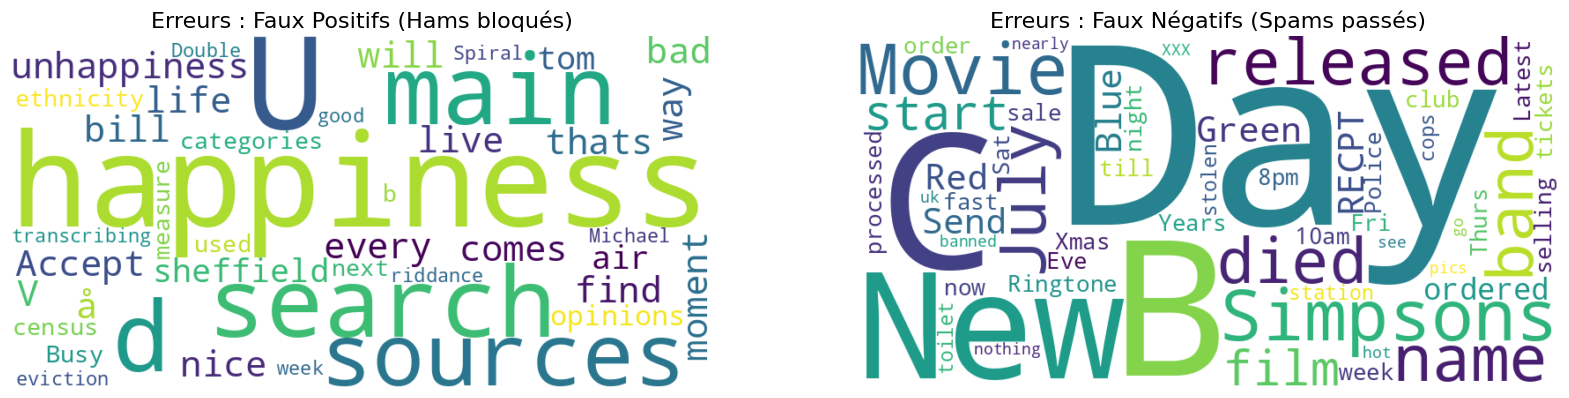

In [11]:
# Point sur les erreurs


y_true_np = np.array(test_ds['label'])

# Mask pour extraire les FP 
mask_fp = (y_true_np == 0) & (y_pred_dl == 1)
# Mask pour extraire les FN
mask_fn = (y_true_np == 1) & (y_pred_dl == 0)

df_fp = test_ds.to_pandas()[mask_fp]
df_fn = test_ds.to_pandas()[mask_fn]

# Visualisation des mots fréquents
text_fp = ' '.join(df_fp['text'].tolist())
text_fn = ' '.join(df_fn['text'].tolist())

plt.figure(figsize=(20, 10))

# Faux Positifs (Ham bloqués à tort)
plt.subplot(1, 2, 1)
wc_fp = WordCloud(width=800, height=400, background_color='white').generate(text_fp)
plt.imshow(wc_fp, interpolation='bilinear')
plt.title('Erreurs : Faux Positifs (Hams bloqués)', fontsize=16)
plt.axis('off')

# Faux Négatifs (Spams laissés passés)
plt.subplot(1, 2, 2)
wc_fn = WordCloud(width=800, height=400, background_color='White').generate(text_fn)
plt.imshow(wc_fn, interpolation='bilinear')
plt.title('Erreurs : Faux Négatifs (Spams passés)', fontsize=16)
plt.axis('off')

plt.show()

## 8. Conclusion et Recommandations

### L'analyse de nos deux nuages de mots montre que le modèle bloque à tort (Faux Positifs) des messages sains qui relèvent d'un lexique plutôt abstrait ou émotionnel. À l'inverse, il laisse passer (Faux Négatifs) de rares spams basés sur des termes très directs, familiers .

### Pour y remédier en production, la recommandation principale est d'appliquer une fonction Softmax pour obtenir des probabilités et intégrer un seuil de décision ajustable (ex: bloquer uniquement au-dessus de 80% de certitude) afin de protéger l'utilisateur.

### Enfin, une piste majeure d'amélioration serait de tester un modèle nativement pré-entraîné sur la cybercriminalité, tel que distilbert-base-uncased-spam-detection.